# Deriving PFES Partitioning Thresholds from Empirical Distributions

This notebook derives the PFES partitioning thresholds (PF-Enriched/Neutral/Depleted) reported in the paper.

**Approach:** For each PFES score column (overall and six attribute-level scores), KDE-smoothed p-value lookup tables are fitted to the empirical distributions of pathogenic and control variants. Thresholds are defined at p < 0.05 against each respective distribution:

- **PF-Enriched**: variant score significantly deviates from the control distribution (p_enriched < 0.05)
- **PF-Depleted**: variant score significantly deviates from the pathogenic distribution (p_depleted < 0.05)
- **PF-Neutral**: score is statistically consistent with both distributions

**Input data:**
- Case (pathogenic): `../data/case_pfes.tsv`
- Control (benign + common population): `../data/control_pfes.tsv`

> ⚠️ **Note:** Because HGMD professional data cannot be made public, the case dataset has been redacted. Running this notebook locally may therefore produce threshold values that differ from those reported in the paper.

# 1. Load data

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

case = pd.read_csv('../data/case_pfes.tsv', delimiter='\t')
control = pd.read_csv('../data/control_pfes.tsv', delimiter='\t')

# case.replace(0, np.nan, inplace=True)
# control.replace(0, np.nan, inplace=True)

home_dir = '..'

SCORE_COLS     = ['PFES', 'PFES_Physicochemical', 'PFES_Structure',
                  'PFES_Domain', 'PFES_Modification', 'PFES_Function', 'PFES_PPI']
N_STEPS        = 10_000

print(f"Case:    {len(case):,} variants (read from ../data/case_pfes.tsv)")
print(f"Control: {len(control):,} variants (read from ../data/control_pfes.tsv)")

Case:    85,321 variants (read from ../data/case_pfes.tsv)
Control: 130,832 variants (read from ../data/control_pfes.tsv)


## Fill NAN score?

In [27]:
fillna = True

if fillna:
    case.fillna(0, inplace=True)
    control.fillna(0, inplace=True)

# 2. Build smoothed p-value lookup using KDE

For each score column:
- `p_case` = P(X ≤ v | case) — left-tail probability under the pathogenic distribution
- `p_control` = P(X ≥ v | control) — right-tail probability under the control distribution

**Partitioning criteria (p < 0.05):**

- **PF-Enriched**: p_control < 0.05 — the variant's score is significantly high relative to the control distribution, indicating enrichment for pathogenic-associated protein features
- **PF-Depleted**: p_case < 0.05 — the variant's score is significantly low relative to the pathogenic distribution, indicating enrichment for benign-associated protein features
- **PF-Neutral**: neither condition is met — the score is statistically consistent with both distributions



In [28]:
def kde_cdf(data, values):
    """Evaluate the KDE-smoothed CDF of `data` at each point in `values`."""
    kde = stats.gaussian_kde(data)
    # Integrate from -inf to each value via cumulative trapezoid
    # Use a grid finer than `values` for accurate integration
    grid  = np.linspace(data.min() - 3 * data.std(),
                        data.max() + 3 * data.std(), 5_000)
    pdf   = kde(grid)
    cdf_grid = np.cumsum(pdf) * (grid[1] - grid[0])
    cdf_grid /= cdf_grid[-1]                          # normalise to [0, 1]
    return np.interp(values, grid, cdf_grid)          # interpolate to target values


records = []
for col in SCORE_COLS:
    c  = case[col].dropna().values
    ct = control[col].dropna().values

    # if col in PRESENCE_BASED:
    #     records.append({'score_col': col, 'pfes_value': 0.0,
    #                     'p_case': np.nan, 'p_control': np.nan,
    #                     'presence_based': True})
    #     continue

    lo   = min(c.min(), ct.min())
    hi   = max(c.max(), ct.max())
    vals = np.linspace(lo, hi, N_STEPS)

    cdf_ctrl = kde_cdf(ct, vals)
    cdf_case = kde_cdf(c,  vals)

    for v, p_case, p_control in zip(vals, cdf_case, 1 - cdf_ctrl):
        records.append({'score_col': col, 'pfes_value': round(v, 6),
                        'p_case': round(float(p_case), 6),
                        'p_control': round(float(p_control), 6)})

lookup = pd.DataFrame(records)
lookup.to_csv(f'{home_dir}/results/pfes_pvalue_lookup.tsv', sep='\t', index=False)
print(f"Saved {len(lookup):,} rows to {home_dir}/results/pfes_pvalue_lookup.tsv")

Saved 70,000 rows to ../results/pfes_pvalue_lookup.tsv


# 3. Derive thresholds from smoothed lookup (p < 0.05)

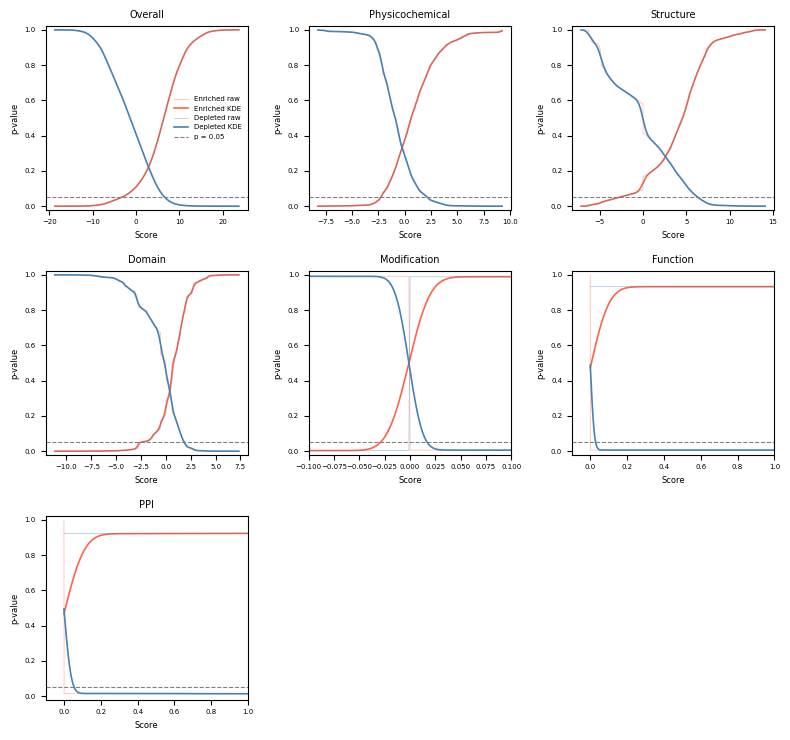

In [29]:

thresholds = {}
for col in SCORE_COLS:
    # if col in PRESENCE_BASED:
    #     thresholds[col] = {'enriched': 0.0, 'depleted': np.nan}
    #     continue
    sub = lookup[lookup['score_col'] == col]
    enr = sub[sub['p_control'] < 0.05]['pfes_value']
    dep = sub[sub['p_case'] < 0.05]['pfes_value']
    thresholds[col] = {
        'enriched': max(enr.min(),0) if not enr.empty else np.nan,
        'depleted': min(dep.max(),0) if not dep.empty else np.nan,
    }

thresh_df = pd.DataFrame(thresholds).T
thresh_df.index.name = 'score_col'

pcols = [c for c in SCORE_COLS]# if c not in PRESENCE_BASED]
ncols = 3
nrows = int(np.ceil(len(pcols) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(8, nrows * 2.5))
axes = axes.flatten()

for ax in axes[len(pcols):]:
    ax.set_visible(False)

for ax, col in zip(axes, pcols):
    c  = case[col].dropna().values
    ct = control[col].dropna().values

    lo   = min(c.min(), ct.min())
    hi   = max(c.max(), ct.max())
    vals = np.linspace(lo, hi, N_STEPS)

    # Raw empirical
    p_enr_raw = np.array([np.mean(ct >= v) for v in vals])
    p_dep_raw = np.array([np.mean(c  <= v) for v in vals])

    # KDE-smoothed (from lookup)
    sub       = lookup[lookup['score_col'] == col].set_index('pfes_value')
    p_enr_kde = np.interp(vals, sub.index, sub['p_case'])
    p_dep_kde = np.interp(vals, sub.index, sub['p_control'])

    ax.plot(vals, p_enr_raw, color='tomato',    lw=0.6, alpha=0.4, label='Enriched raw')
    ax.plot(vals, p_enr_kde, color='tomato',    lw=1.2,            label='Enriched KDE')
    ax.plot(vals, p_dep_raw, color='steelblue', lw=0.6, alpha=0.4, label='Depleted raw')
    ax.plot(vals, p_dep_kde, color='steelblue', lw=1.2,            label='Depleted KDE')
    ax.axhline(0.05, color='gray', lw=0.8, ls='--', label='p = 0.05')

    label = col.replace('PFES_', '')
    ax.set_title(label if label != 'PFES' else 'Overall', fontsize=7)
    ax.set_xlabel('Score', fontsize=6)
    ax.set_ylabel('p-value', fontsize=6)
    ax.tick_params(labelsize=5)
    ax.set_ylim(-0.02, 1.02)
    if col == 'PFES_Modification':
        ax.set_xlim(-0.1, 0.1)
    elif col == 'PFES_Function' or col == 'PFES_PPI':
        ax.set_xlim(-0.1, 1)

axes[0].legend(fontsize=5, frameon=False)
plt.tight_layout()
plt.show()

# 4. Distribution histogram with smoothed thresholds

In [35]:
case.replace(0.0, np.nan)

,Gene,UniProt,ResID,RefAA,AltAA,PFES,PFES_Physicochemical,PFES_Structure,PFES_Domain,PFES_Function,PFES_Modification,PFES_PPI
0,A2ML1,A8K2U0,356,P,R,2.24,1.6196,0.6183,NaN,NaN,NaN,NaN
1,A2ML1,A8K2U0,822,V,I,3.94,-2.2356,6.1710,NaN,NaN,NaN,NaN
2,A4GALT,Q9NPC4,211,Q,E,3.18,-1.3828,4.7889,-0.2240,NaN,NaN,NaN
3,AAAS,Q9NRG9,1,M,V,-5.30,-2.1029,-3.1931,NaN,NaN,NaN,NaN
4,AAAS,Q9NRG9,41,Q,R,-2.30,-1.4897,-0.2563,-0.5548,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
85316,ZP3,P21754,387,V,M,0.81,-2.1029,1.2299,1.6842,NaN,NaN,NaN
85317,ZP4,Q12836,447,C,Y,16.19,3.8233,10.7185,1.6465,NaN,NaN,NaN
85318,ZPBP,Q9BS86,217,H,L,4.92,0.3193,5.1574,-0.5548,NaN,NaN,NaN
85319,ZSWIM6,Q9HCJ5,1163,R,W,-1.23,0.0459,-0.7165,-0.5548,NaN,NaN,NaN


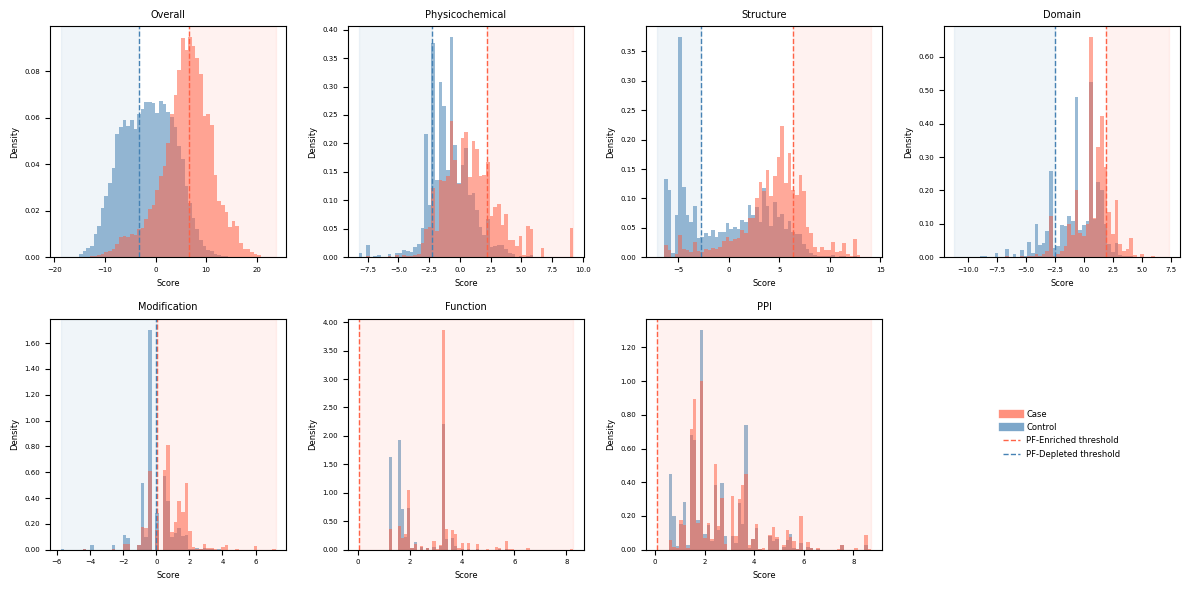

Thresholds (p < 0.05):
                      enriched  depleted
score_col                               
PFES                     6.649    -3.355
PFES_Physicochemical     2.174    -2.281
PFES_Structure           6.355    -2.776
PFES_Domain              1.857    -2.547
PFES_Modification        0.017    -0.030
PFES_Function            0.030       NaN
PFES_PPI                 0.056       NaN


In [ ]:


fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

if fillna:
    case.replace(0.0, np.nan, inplace=True)
    control.replace(0.0, np.nan, inplace=True)
    
for ax, col in zip(axes, SCORE_COLS):
    c  = case[col].dropna().values
    ct = control[col].dropna().values
    t  = thresholds[col]

    lo   = min(c.min(), ct.min())
    hi   = max(c.max(), ct.max())
    bins = np.linspace(lo, hi, 60)

    ax.hist(ct, bins=bins, density=True, alpha=0.55, color='steelblue')
    ax.hist(c,  bins=bins, density=True, alpha=0.55, color='tomato')

    if not np.isnan(t['enriched']):
        ax.axvline(t['enriched'], color='tomato',    lw=1.0, ls='--')
        ax.axvspan(t['enriched'], hi, alpha=0.08, color='tomato')
    if not np.isnan(t['depleted']):
        ax.axvline(t['depleted'], color='steelblue', lw=1.0, ls='--')
        ax.axvspan(lo, t['depleted'], alpha=0.08, color='steelblue')

    label = col.replace('PFES_', '')
    ax.set_title(label if label != 'PFES' else 'Overall', fontsize=7)
    ax.set_xlabel('Score', fontsize=6)
    ax.set_ylabel('Density', fontsize=6)
    ax.tick_params(labelsize=5)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

axes[-1].axis('off')
handles = [
    plt.Line2D([0], [0], color='tomato',    alpha=0.7, lw=6, label='Case'),
    plt.Line2D([0], [0], color='steelblue', alpha=0.7, lw=6, label='Control'),
    plt.Line2D([0], [0], color='tomato',    lw=1.0, ls='--', label='PF-Enriched threshold'),
    plt.Line2D([0], [0], color='steelblue', lw=1.0, ls='--', label='PF-Depleted threshold'),
]
axes[-1].legend(handles=handles, fontsize=6, frameon=False, loc='center')

# label threshold lines only in the last subplot


plt.tight_layout()
plt.show()

print("Thresholds (p < 0.05):")
print(thresh_df.to_string(float_format='{:.3f}'.format))